# House Price Prediction

Goal: build a regression model to predict house prices with feature engineering,
missing-value handling, transformations, model selection, and residual analysis.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

DATA_PATH = Path("data.csv")
ARTIFACTS_DIR = Path("artifacts")
MODEL_PATH = ARTIFACTS_DIR / "best_house_price_model.joblib"
TARGET = "price"
ARTIFACTS_DIR.mkdir(exist_ok=True)

## Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [4]:
print("Missing values:")
print(df.isna().sum())

print("\nRows with price <= 0:", (df[TARGET] <= 0).sum())

Missing values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Rows with price <= 0: 49


In [5]:
df[df[TARGET] > 0].describe().T

,count,mean,std,min,25%,50%,75%,max
price,4551.0,557905.899138,563929.871279,7800.0,326264.285715,465000.00,657500.0,26590000.0
bedrooms,4551.0,3.394639,0.904595,0.0,3.000000,3.00,4.0,9.0
bathrooms,4551.0,2.155021,0.776351,0.0,1.750000,2.25,2.5,8.0
sqft_living,4551.0,2132.372226,955.949708,370.0,1460.000000,1970.00,2610.0,13540.0
sqft_lot,4551.0,14835.280598,35964.077825,638.0,5000.000000,7680.00,10978.0,1074218.0
floors,4551.0,1.512195,0.538531,1.0,1.000000,1.50,2.0,3.5
waterfront,4551.0,0.006592,0.080932,0.0,0.000000,0.00,0.0,1.0
view,4551.0,0.234674,0.765373,0.0,0.000000,0.00,0.0,4.0
condition,4551.0,3.449352,0.675160,1.0,3.000000,3.00,4.0,5.0
sqft_above,4551.0,1822.221710,854.452888,370.0,1190.000000,1590.00,2300.0,9410.0


## EDA

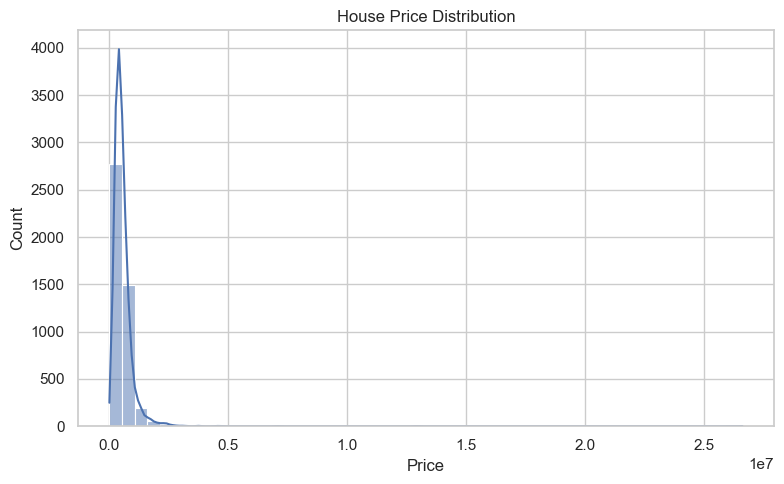

In [6]:
valid_df = df[df[TARGET] > 0].copy()

plt.figure(figsize=(8, 5))
sns.histplot(valid_df[TARGET], bins=50, kde=True)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "price_distribution.png", dpi=160)
plt.show()

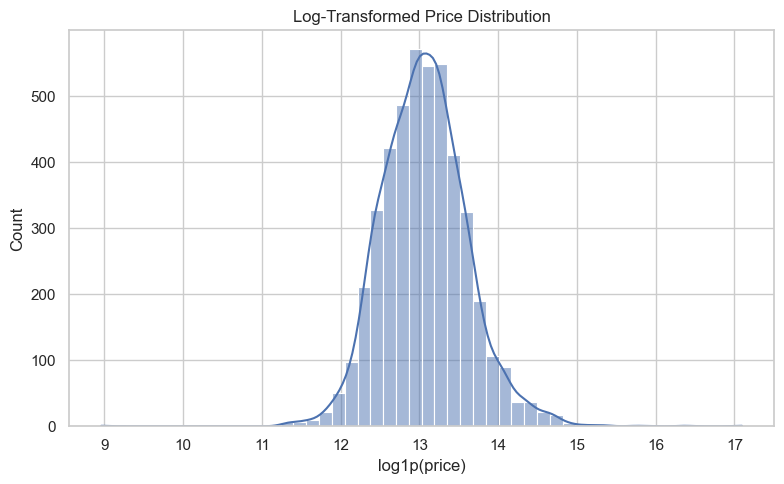

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(valid_df[TARGET]), bins=50, kde=True)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("log1p(price)")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "log_price_distribution.png", dpi=160)
plt.show()

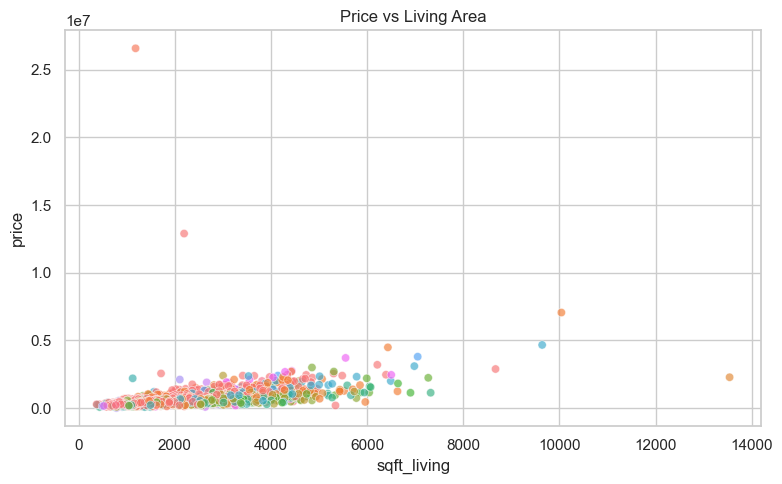

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=valid_df, x="sqft_living", y=TARGET, hue="city", legend=False, alpha=0.65)
plt.title("Price vs Living Area")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "price_vs_sqft_living.png", dpi=160)
plt.show()

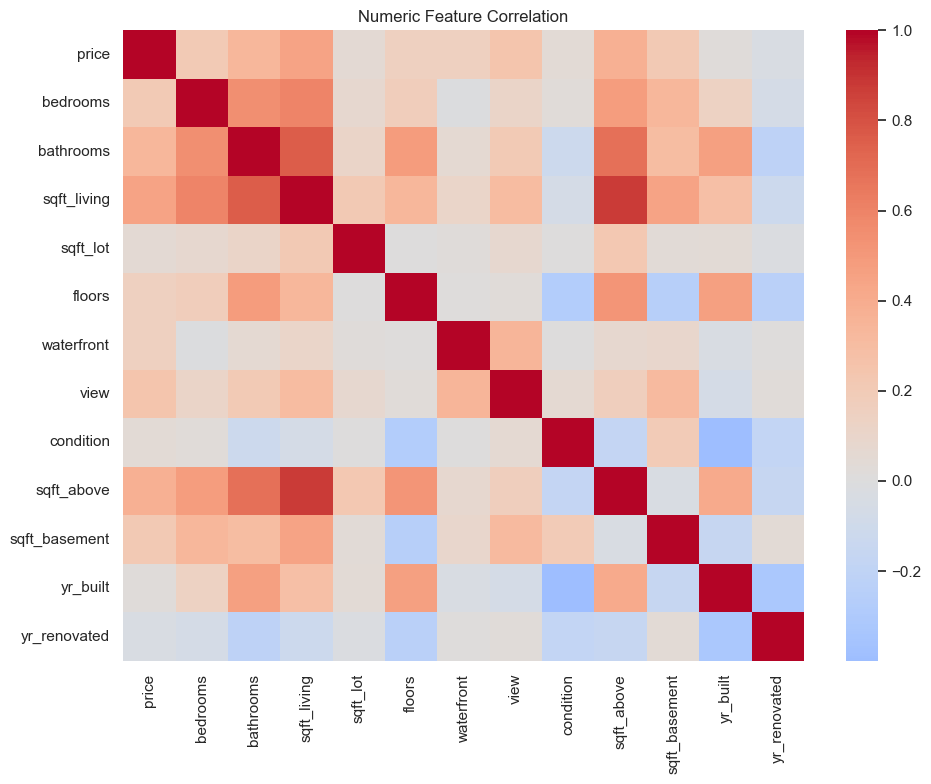

In [9]:
numeric_corr = valid_df.select_dtypes(include=[np.number]).corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_corr, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "correlation_heatmap.png", dpi=160)
plt.show()

## Feature Engineering

In [10]:
def prepare_features(data):
    prepared = data.copy()
    prepared["date"] = pd.to_datetime(prepared["date"], errors="coerce")
    prepared["sale_year"] = prepared["date"].dt.year
    prepared["sale_month"] = prepared["date"].dt.month
    prepared["zipcode"] = prepared["statezip"].str.extract(r"(\d{5})", expand=False)
    prepared["house_age"] = prepared["sale_year"] - prepared["yr_built"]
    prepared["was_renovated"] = (prepared["yr_renovated"] > 0).astype(int)
    return prepared


prepared = prepare_features(df)
prepared = prepared[prepared[TARGET] > 0].copy()
prepared.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,street,city,statezip,country,sale_year,sale_month,zipcode,house_age,was_renovated
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,2014,5,98133,59,1
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,...,0,709 W Blaine St,Seattle,WA 98119,USA,2014,5,98119,93,0
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,2014,5,98042,48,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,0,857 170th Pl NE,Bellevue,WA 98008,USA,2014,5,98008,51,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,1992,9105 170th Ave NE,Redmond,WA 98052,USA,2014,5,98052,38,1


## Preprocessing

In [11]:
drop_columns = ["price", "street", "country", "date", "statezip"]
log_numeric_features = ["sqft_living", "sqft_lot", "sqft_above", "sqft_basement"]
other_numeric_features = [
    "bedrooms",
    "bathrooms",
    "floors",
    "waterfront",
    "view",
    "condition",
    "yr_built",
    "yr_renovated",
    "sale_year",
    "sale_month",
    "house_age",
    "was_renovated",
]
categorical_features = ["city", "zipcode"]

X = prepared.drop(columns=drop_columns)
y = prepared[TARGET]

log_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("log_numeric", log_numeric_pipeline, log_numeric_features),
        ("numeric", numeric_pipeline, other_numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

## Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train.shape, X_test.shape

((3640, 18), (911, 18))

## Model Training And Comparison

In [13]:
def make_model(regressor):
    return TransformedTargetRegressor(
        regressor=Pipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", regressor),
            ]
        ),
        func=np.log1p,
        inverse_func=np.expm1,
    )


models = {
    "Linear Regression": make_model(LinearRegression()),
    "Random Forest": make_model(
        RandomForestRegressor(
            n_estimators=120,
            random_state=42,
            n_jobs=-1,
            max_depth=18,
        )
    ),
    "Gradient Boosting": make_model(
        GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        )
    ),
}

results = []
fitted_models = {}
predictions_by_model = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = np.maximum(model.predict(X_test), 0)
    results.append(
        {
            "model": name,
            "rmse": root_mean_squared_error(y_test, predictions),
            "mae": mean_absolute_error(y_test, predictions),
        }
    )
    fitted_models[name] = model
    predictions_by_model[name] = predictions

results_df = pd.DataFrame(results).sort_values(["rmse", "mae"])
results_df.to_csv(ARTIFACTS_DIR / "model_comparison.csv", index=False)
results_df

,model,rmse,mae
0,Linear Regression,173631.332755,87215.506308
2,Gradient Boosting,220853.559538,110868.853111
1,Random Forest,225956.714892,112903.594966


## Residual Analysis

In [14]:
best_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_name]
best_predictions = predictions_by_model[best_name]
residuals = y_test - best_predictions

print("Best model:", best_name)
print("RMSE:", root_mean_squared_error(y_test, best_predictions))
print("MAE:", mean_absolute_error(y_test, best_predictions))

Best model: Linear Regression
RMSE: 173631.33275475117
MAE: 87215.50630832017


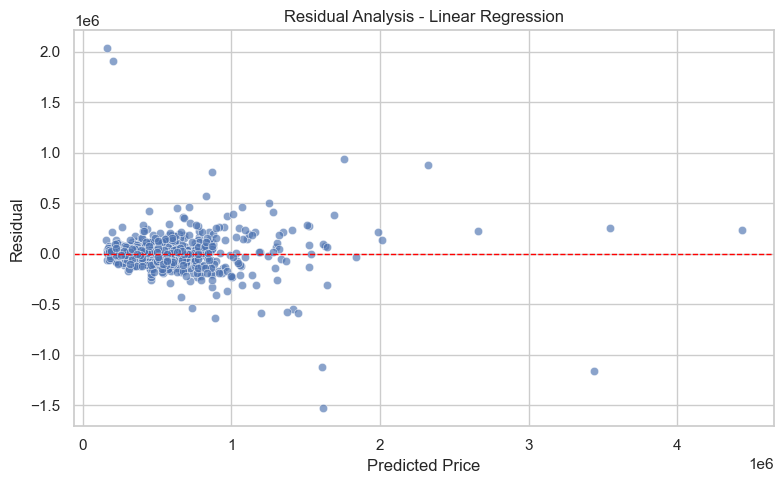

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.65)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Residual Analysis - {best_name}")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "residual_plot.png", dpi=160)
plt.show()

## Save Best Model

In [16]:
joblib.dump(best_model, MODEL_PATH)
MODEL_PATH

WindowsPath('artifacts/best_house_price_model.joblib')

## Example Prediction

In [17]:
loaded_model = joblib.load(MODEL_PATH)

sample = pd.DataFrame(
    [
        {
            "bedrooms": 3.0,
            "bathrooms": 2.0,
            "sqft_living": 1800,
            "sqft_lot": 5000,
            "floors": 1.0,
            "waterfront": 0,
            "view": 0,
            "condition": 3,
            "sqft_above": 1500,
            "sqft_basement": 300,
            "yr_built": 1995,
            "yr_renovated": 0,
            "city": "Seattle",
            "sale_year": 2014,
            "sale_month": 6,
            "zipcode": "98103",
            "house_age": 19,
            "was_renovated": 0,
        }
    ]
)

predicted_price = loaded_model.predict(sample)[0]
print(f"Predicted price: ${predicted_price:,.2f}")

Predicted price: $616,953.33
